In [1]:
import pandas as pd
from CCA_utils import *

## Baseline Model Panel

In [ ]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 52
freq = 'W'

cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr']
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000



C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_32744\3488824655.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_prices['Date'] = pd.to_datetime(oil_prices['Date'])
C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_32744\3488824655.py:14: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  oil_futures['date'] = pd.to_datetime(oil_futures['date'])


## Model 1: Specific data

In [ ]:

#Join oil prices and oil futures
oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['Date'] = pd.to_datetime(oil_prices['Date'])
oil_futures = pd.read_csv('../data/processed/Oil/oil_futures.csv')
oil_futures['date'] = pd.to_datetime(oil_futures['date'])

cca_panel_df = cca_panel_df.merge(oil_prices[['Date','Brent']], left_on='date', right_on='Date', how='left')
cca_panel_df = cca_panel_df.merge(oil_futures[['date','Brent_12m']],on='date',how='left')

oil_prod = pd.read_csv('../data/processed/Oil/crude_oil_production.csv')
oil_prod = oil_prod.rename(columns={oil_prod.columns[0]: 'country'})
oil_prod = oil_prod.melt(id_vars='country', var_name='year', value_name='oil_production_Mt_yr')
oil_prod['year'] = oil_prod['year'].astype(int)

# UAE for Abu Dhabi and Dubai
uae = oil_prod[oil_prod['country'] == 'United Arab Emirates'].copy()
for name in ['Abu Dhabi', 'Dubai']:
    rows = uae.copy()
    rows['country'] = name
    oil_prod = pd.concat([oil_prod, rows], ignore_index=True)

cca_panel_df['year'] = cca_panel_df['date'].dt.year
cca_panel_df = cca_panel_df.merge(oil_prod[['year', 'country', 'oil_production_Mt_yr']], 
                                   on=['country', 'year'], how='left')
cca_panel_df['oil_production_Mt_yr'] = cca_panel_df['oil_production_Mt_yr'].fillna(0)
cca_panel_df['oil_production_Mt_yr'] = cca_panel_df['oil_production_Mt_yr'].astype(int)

In [ ]:
results = pd.DataFrame()
eta = 0.75

for country, group in cca_panel_df.groupby('country'):

    df = group.copy().sort_values('date').reset_index(drop=True)
        
    # --- Unit conversions ---
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

        # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                df['external_debt_mn_usd'], r_f
            )
        ]

    df['futures_term'] = (df['Brent_12m']/df['Brent']) ** eta
    df['LCL_aug'] = df['LCL_usd'] * df['futures_term']


    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_aug'] / df['LCL_aug'].shift(1))
    
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor

    # --- Solve CCA with augmented LCL ---
    out = {k: [] for k in ['implied_V', 'implied_sigma_V', 'cca_converged',
                            'distance_to_distress', 'default_prob',
                            'model_spread_bps', 'put_value', 'risky_debt',
                            'leverage']}

    for i, row in df.iterrows():
        cca = solve_CCA(row['LCL_aug'], row['sigma_lcl'], row['B_f'],
                        r_f.iloc[i], T)
        risk = compute_risk(cca['V'], cca['sigma_V'], row['B_f'],
                           r_f.iloc[i], T)

        out['implied_V'].append(cca['V'])
        out['implied_sigma_V'].append(cca['sigma_V'])
        out['cca_converged'].append(cca['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])


START_DATE = '2014-01-01'
END_DATE = '2024-12-31'

results = results[
    (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
].copy()


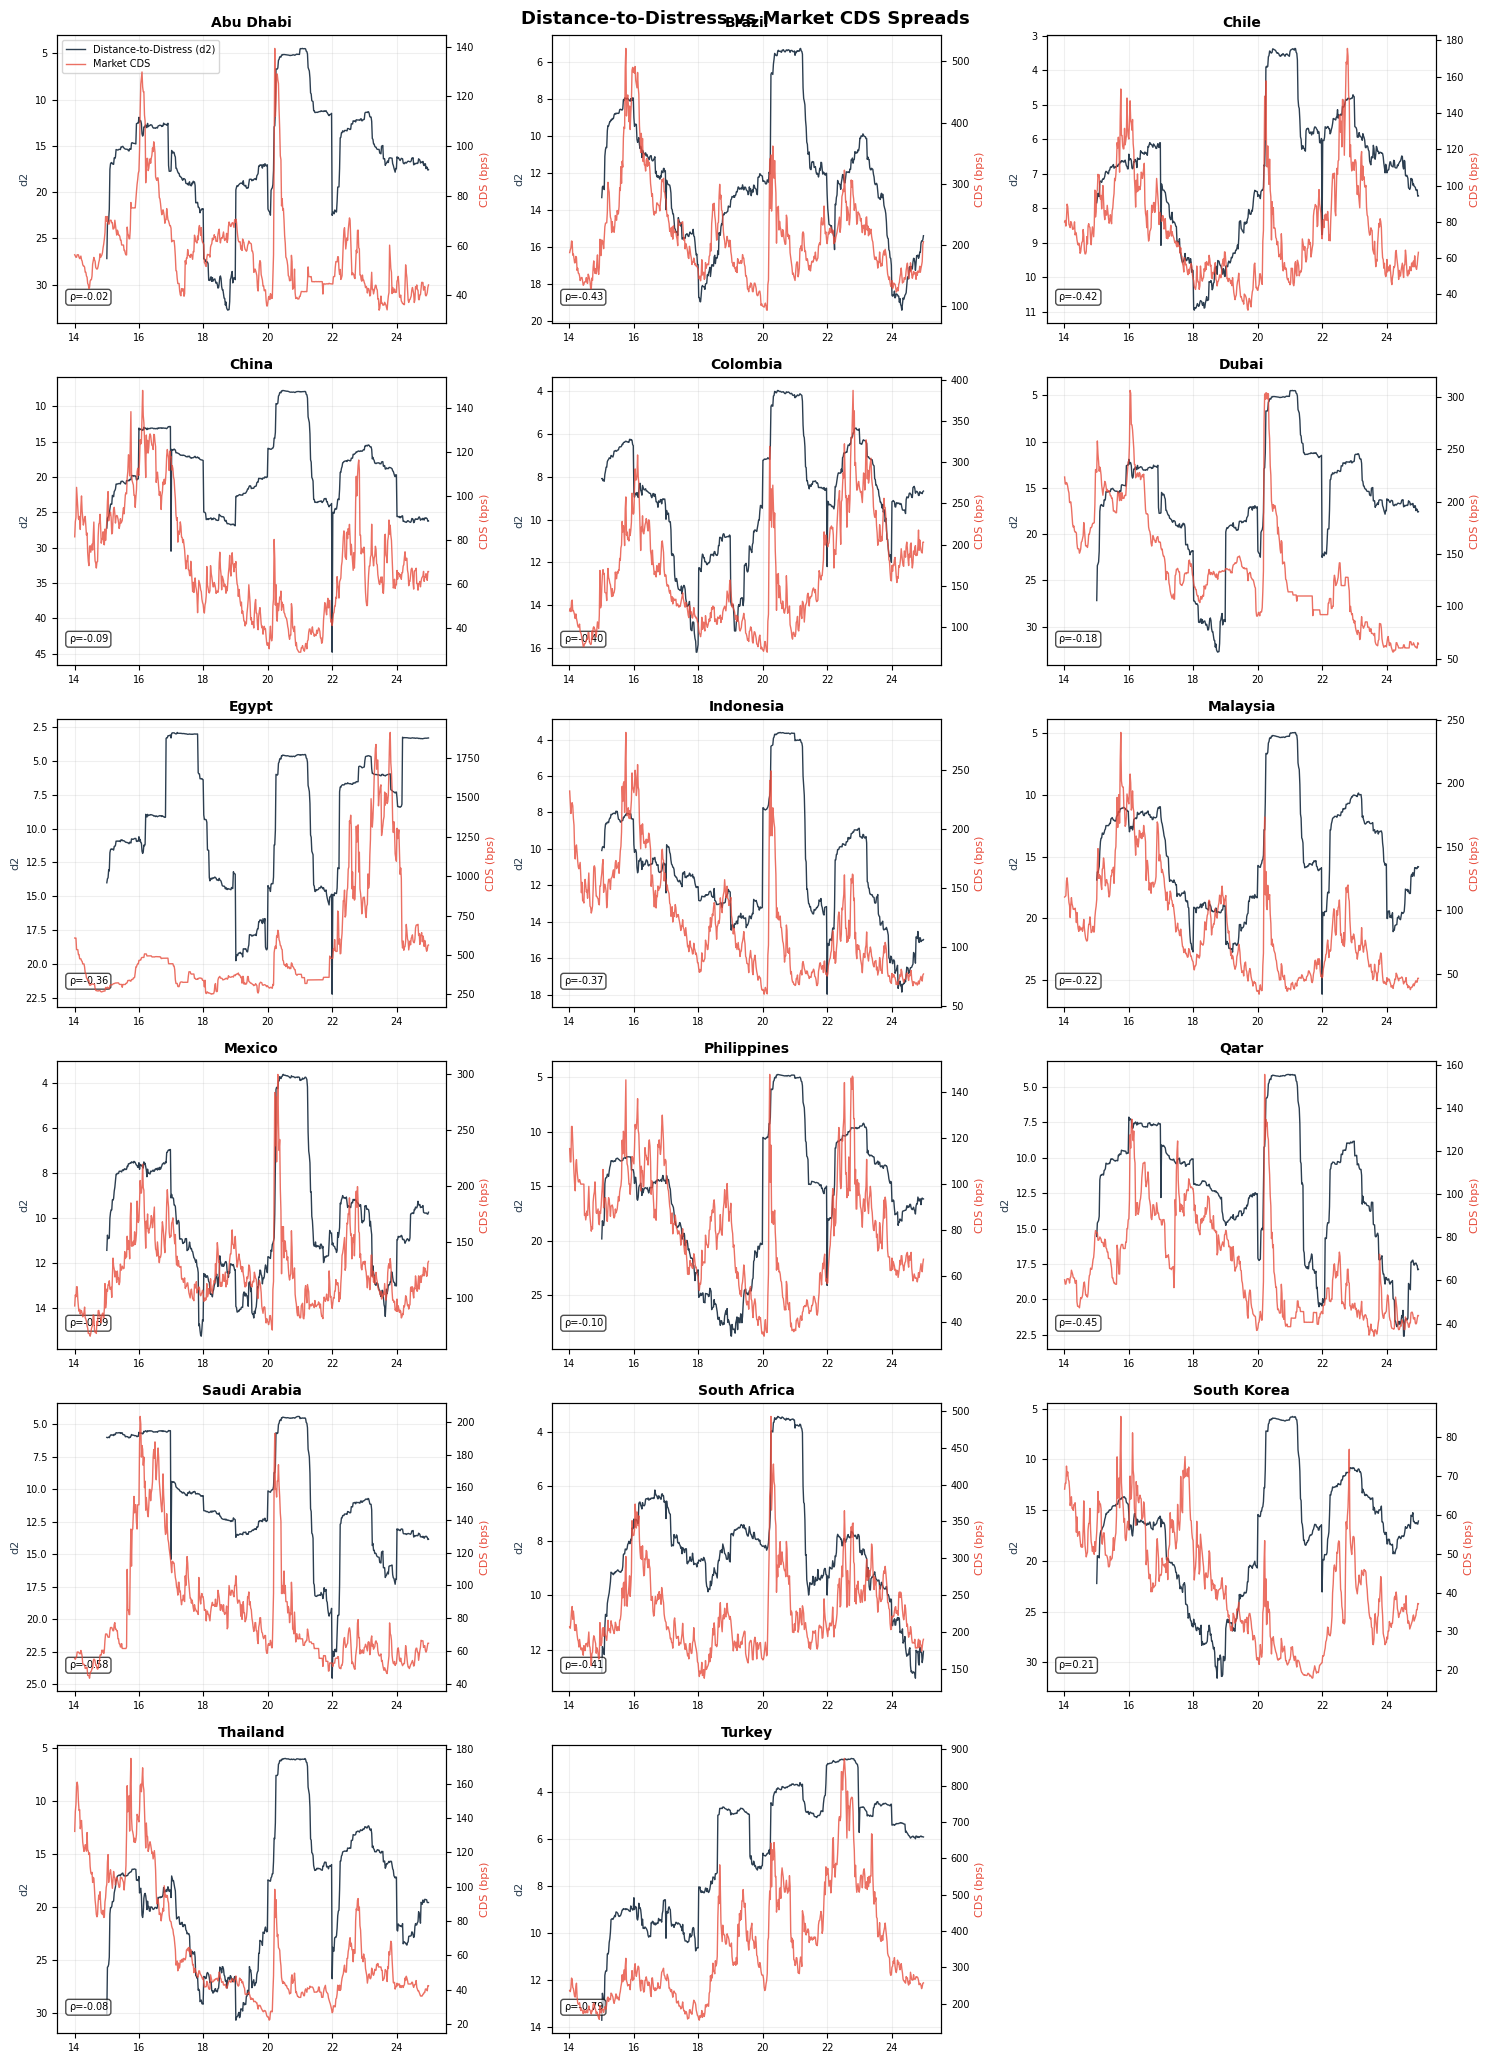

In [18]:
d2_vs_cds = plot_d2_vs_cds(results)

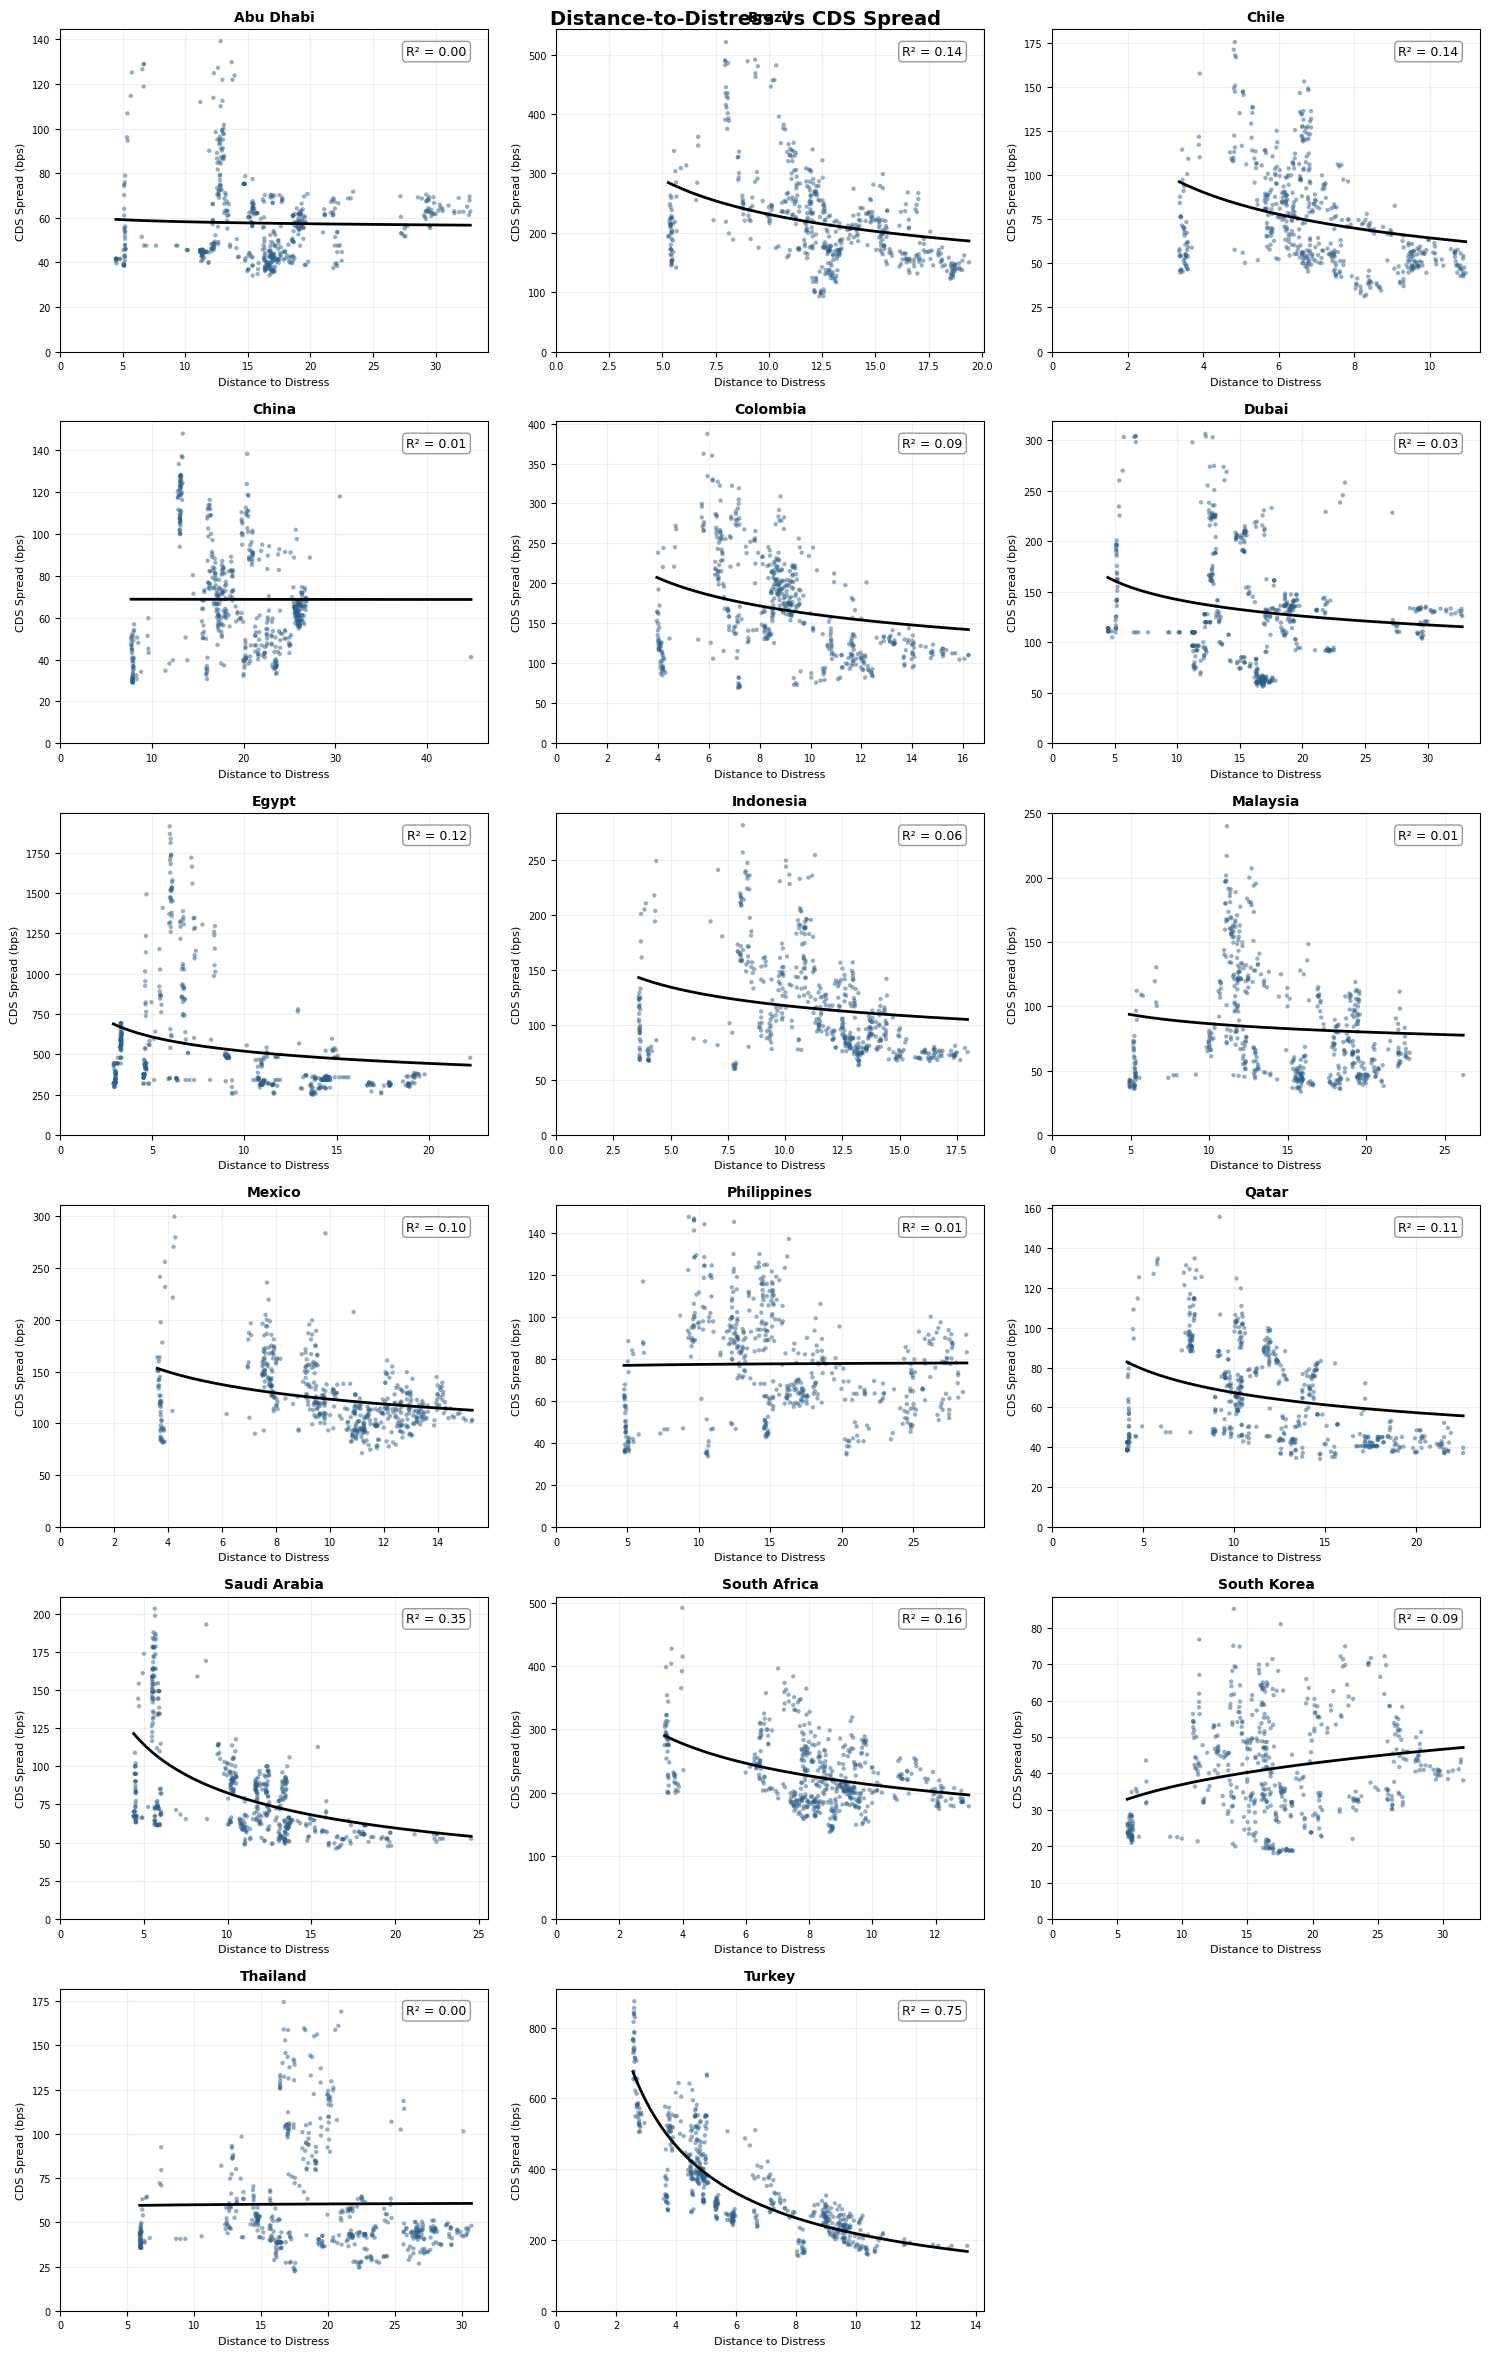

In [19]:
d2_scatter = plot_d2_scatter(results)

In [20]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 4, 13],
    horizon_labels=['1w', '1m', '3m'],
)
display

,Country,N,ρ (1w),Dir (1w),ρ (1m),Dir (1m),ρ (3m),Dir (3m)
0,Abu Dhabi,522,-0.10**,50%,-0.22***,50%,-0.28***,45%
1,Brazil,522,-0.19***,59%,-0.28***,63%,-0.40***,61%
2,Chile,522,-0.11**,58%,-0.19***,54%,-0.29***,58%
3,China,522,-0.02,54%,-0.04,51%,-0.11**,50%
4,Colombia,522,-0.07,57%,-0.08*,58%,-0.15***,55%
5,Dubai,522,-0.22***,50%,-0.30***,51%,-0.39***,51%
6,Egypt,522,-0.02,53%,0.04,51%,-0.03,45%
7,Indonesia,522,-0.08*,54%,-0.08*,53%,-0.21***,56%
8,Malaysia,522,-0.07,54%,-0.11***,53%,-0.30***,55%
9,Mexico,522,-0.11**,56%,-0.24***,54%,-0.36***,58%
